# Text Classification - Amazon vs IMDb Reviews
### LING 539 Kaggle Competition

The competition gives us a bunch of text reviews and asks us to figure out which of three categories they belong to:
- **0** - Amazon product review (books, music, etc.)
- **1** - Positive IMDb movie/TV review
- **2** - Negative IMDb movie/TV review

I didn't actually know what the labels meant when I started -- the competition just said "3-class classification". Had to look at the data to figure it out. This notebook walks through what I found, what I tried, and what ended up working.

In [2]:
import re
import html
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

LABEL_NAMES = {0: 'Amazon review', 1: 'IMDb positive', 2: 'IMDb negative'}

## 1. Loading the data

Training set has ~70k rows with an ID, the text, and the label. Test set is the same but without labels.

In [3]:
train = pd.read_csv('../data/train.csv').dropna(subset=['TEXT'])
test  = pd.read_csv('../data/test.csv').fillna('')

print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head(3)

Train: (70310, 3)  |  Test: (17580, 2)


,ID,TEXT,LABEL
0,327995652116863138,Carolyn Baker defines the niche of helping peo...,0
1,11848336500074516230,Just getting released from a six month drug re...,1
2,8453485550425672763,I was greatly dissappointed when I popped this...,0


## 2. Looking at the data before doing anything

Before writing a single line of model code I wanted to understand what's actually in here. Most of the improvements in this project came from just carefully reading the data.

### Label distribution

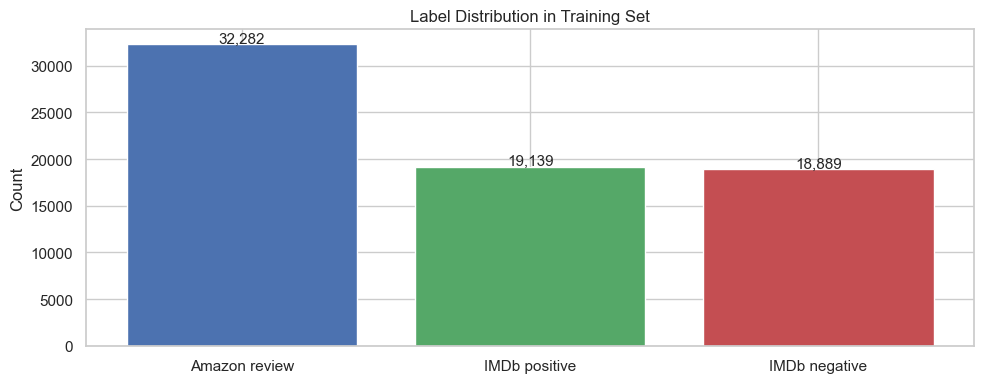

LABEL
0    32282
1    19139
2    18889


In [4]:
counts = train.LABEL.value_counts().sort_index()
fig, ax = plt.subplots()
bars = ax.bar([LABEL_NAMES[i] for i in counts.index], counts.values,
              color=['#4c72b0','#55a868','#c44e52'])
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{v:,}', ha='center', fontsize=11)
ax.set_title('Label Distribution in Training Set')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(counts.to_string())

Amazon reviews are the biggest class at ~46%, and the two IMDb classes are roughly equal at ~27% each. Not super imbalanced but not balanced either.

I initially used `class_weight='balanced'` thinking it would help, but it actually made things worse. With this kind of mild imbalance, letting the model see the natural distribution works better.

### How long are the reviews?

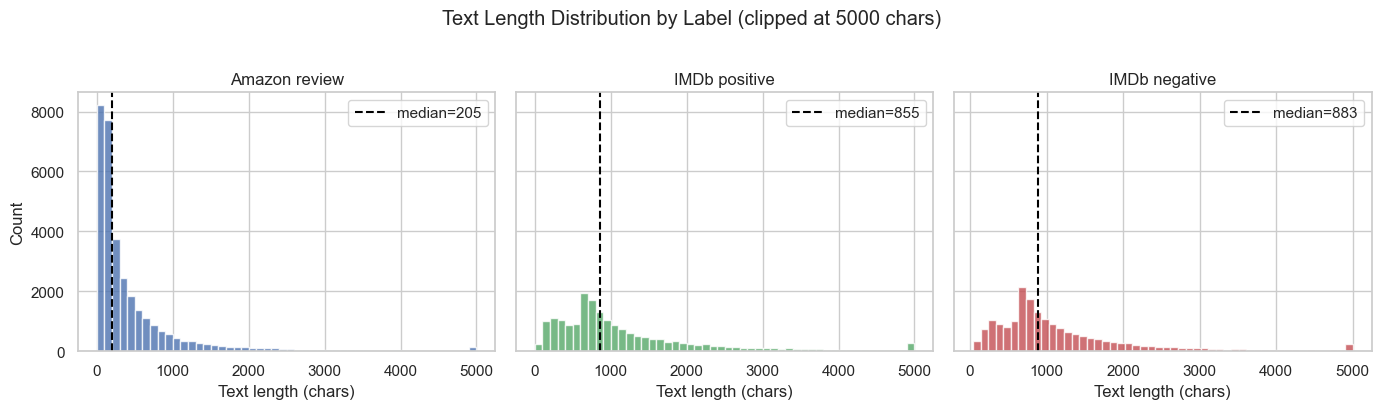

In [5]:
train['text_len'] = train.TEXT.str.len()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ['#4c72b0','#55a868','#c44e52']
for ax, label, color in zip(axes, [0, 1, 2], colors):
    data = train[train.LABEL == label]['text_len'].clip(upper=5000)
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.median(), color='black', linestyle='--', label=f'median={data.median():.0f}')
    ax.set_title(LABEL_NAMES[label])
    ax.set_xlabel('Text length (chars)')
    ax.legend()
axes[0].set_ylabel('Count')
plt.suptitle('Text Length Distribution by Label (clipped at 5000 chars)', y=1.02)
plt.tight_layout()
plt.show()

Amazon reviews are way shorter (median ~205 chars) — things like "Loved it!" or "Great book, arrived quickly". IMDb reviews are much longer, people really go into detail. This length difference is a useful feature so I included it.

### HTML tags — this one surprised me

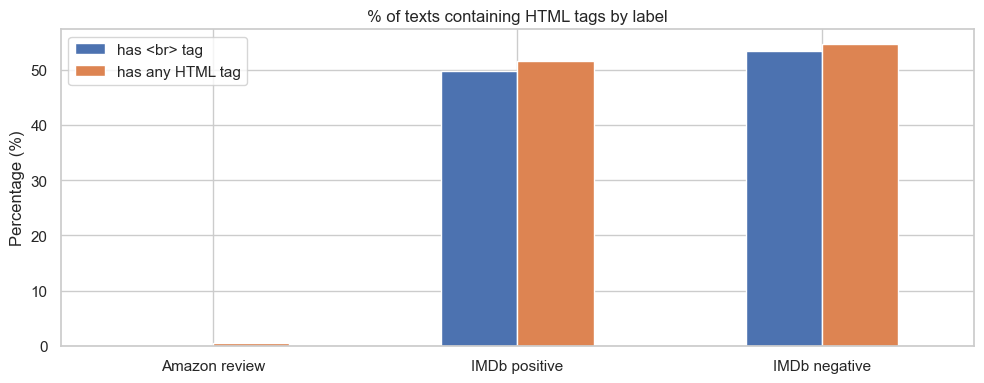

               has_br  has_html
Amazon review     0.0       0.5
IMDb positive    49.7      51.5
IMDb negative    53.3      54.5


In [6]:
train['has_br']   = train.TEXT.str.contains(r'<br', regex=True, case=False)
train['has_html'] = train.TEXT.str.contains(r'<[a-z]', regex=True, case=False)

html_pct = train.groupby('LABEL')[['has_br','has_html']].mean() * 100
html_pct.index = [LABEL_NAMES[i] for i in html_pct.index]

html_pct.plot(kind='bar', color=['#4c72b0','#dd8452'], rot=0)
plt.title('% of texts containing HTML tags by label')
plt.ylabel('Percentage (%)')
plt.legend(['has <br> tag', 'has any HTML tag'])
plt.tight_layout()
plt.show()
print(html_pct.round(1))

Zero Amazon reviews have HTML tags. About half of IMDb reviews do -- they were probably scraped from the website and still have `<br />` line breaks in them.

This ended up being one of the most useful signals. The tricky part is you have to be careful *where* you use it. In my first version I was stripping HTML before running the char n-gram TF-IDF, which meant I was throwing away the signal before the model could see it. Keeping the raw text for char features fixed this -- more on that in the features section.

### Wait — some of these are in Chinese?

I noticed some reviews that looked completely different. Turns out a chunk of them are in Chinese. Checked whether this was spread across all labels or concentrated in one...

In [7]:
def is_chinese(text):
    return bool(re.search(r'[\u4e00-\u9fff]', str(text)))

train['chinese'] = train.TEXT.apply(is_chinese)
test['chinese']  = test.TEXT.apply(is_chinese)

print('=== Chinese text distribution ===')
print(train[train.chinese].LABEL.value_counts())
print(f'\nTotal Chinese rows in train: {train.chinese.sum()}')
print(f'Total Chinese rows in test:  {test.chinese.sum()}')
print('\nSample Chinese text (label 0):')
print(train[train.chinese].TEXT.iloc[0][:300])

=== Chinese text distribution ===
LABEL
0    2427
Name: count, dtype: int64

Total Chinese rows in train: 2427
Total Chinese rows in test:  621

Sample Chinese text (label 0):
那獃子一時興發，掣了釘鈀，叫聲：「去來。」他兩個不顧師父，一齊駕風趕 上，舉釘鈀，使寶杖，望妖精亂打。那妖精戰行者一個已是不能，又見他二人， 怎生抵敵，急回頭，抽身就走。行者喝道：「兄弟們趕上。」那妖精見他們趕得 緊，即將右腳上花鞋脫下來，吹口仙氣，念個咒語，叫：「變！」即變作本身模 樣，使兩口劍舞將來；將身一幌，化一陣清風，徑直回去。這番也只說戰他們不 過，顧命而回，豈知又有這般樣事！也是三藏災星未退，他到洞門前牌樓下，卻 見唐僧在那裏獨坐，他就近前一把抱住，搶了行李，咬斷韁繩，連人和馬，復又 攝將進去不題。

　　

且說八戒閃個空，一鈀把妖精打落地，乃是一隻花鞋。行者看見道：「你這兩個 


Every single Chinese-language review in the training set is label 0. All 2,427 of them, no exceptions. They look like Chinese-language book or product reviews on Amazon, which makes sense given that label 0 is the Amazon category.

So instead of trying to teach the model to handle these, I just wrote a rule: if the text has Chinese characters → label 0. Gets ~621 test rows classified with certainty before any ML runs. Small fraction of the data but it's free accuracy.

### What do the reviews actually look like?

In [8]:
for label in [0, 1, 2]:
    sample = train[train.LABEL == label].sample(1, random_state=7).iloc[0]
    print(f'--- {LABEL_NAMES[label]} ---')
    print(sample.TEXT[:400])
    print(f'  [length: {len(sample.TEXT)} chars, has_html: {sample.has_html}]\n')

--- Amazon review ---
Phoebe is on a mission to find as many birds as possible, not just in her backyard, but the whole world in a race against a devastating cancer determined to end her life.
  [length: 170 chars, has_html: False]

--- IMDb positive ---
Dark Angel is a cross between Huxley's Brave New World and Percy's Love in the Ruins--portraying the not too distant future as a disturbing mixture of chaos and order, both in the worst sense of the word. Once one swallows the premise that all modern technology can be brought to a standstill by "the Pulse," it provides an entertaining landscape for exploring the personalities of and relationships 
  [length: 737 chars, has_html: False]

--- IMDb negative ---
I cannot believe this is a movie.  It really disgusted me and it just plain perverse. Halle Berry and Bruce Willis have shamed the art of cinema.  The casting is a weak spot and a real problem.  The acting just plain ridiculous, the performances were tired and forced.  The story is

## 3. Features

The problem is really two things at once:
1. **Is this Amazon or IMDb?** - structural signals (HTML tags, text length, vocabulary)
2. **Is it positive or negative?** - semantic/sentiment signals

No single feature type handles both well, which is why I ended up combining a few.

### Word TF-IDF

TF-IDF (Term Frequency x Inverse Document Frequency) converts text into a sparse vector. Each dimension is a word or word pair, scored by how distinctive it is for this document versus the whole corpus. Words like "cinematography" score high in movie reviews but near zero in book reviews -- that's the useful signal.

I ran this on **cleaned text** (HTML stripped, lowercase) with unigrams and bigrams. Bigrams let the model treat "not good" as a single feature rather than "not" and "good" separately, which helps with negation.

### Char n-gram TF-IDF - run on raw text

Same idea but at the character level, using 3-5 character sequences. With raw text, character sequences like `"<br "` and `"br />"` become features -- and those HTML fragments are basically a perfect signal for IMDb vs Amazon.

The important thing: run this on **raw text before any cleaning**. In my first attempt I cleaned the text first and lost this signal entirely. That bug cost about 1% accuracy.

### Meta features

In [9]:
# Illustrate meta features
meta_summary = train.groupby('LABEL').agg(
    avg_len   = ('text_len', 'mean'),
    pct_html  = ('has_html', 'mean'),
    pct_br    = ('has_br',   'mean'),
    pct_chinese = ('chinese', 'mean'),
).round(3)
meta_summary.index = [LABEL_NAMES[i] for i in meta_summary.index]
meta_summary.columns = ['avg char length', '% has HTML', '% has <br>', '% Chinese']
print(meta_summary.to_string())

               avg char length  % has HTML  % has <br>  % Chinese
Amazon review          462.807       0.005       0.000      0.075
IMDb positive         1190.716       0.515       0.497      0.000
IMDb negative         1185.012       0.545       0.533      0.000


### Sentence embeddings

TF-IDF treats every word independently -- it has no idea "terrible" and "awful" mean the same thing. Sentence embeddings fix that. I used `all-MiniLM-L6-v2` from the `sentence-transformers` library, which maps each text to a 384-dimensional dense vector that captures meaning and context.

The tradeoff is that embeddings don't capture structural signals like HTML tags or text length. So neither TF-IDF nor embeddings alone is best for this task -- I ended up combining both.

| Feature | Good at | Size |
|---|---|---|
| Word TF-IDF | vocabulary, domain differences | 80k sparse |
| Char TF-IDF | HTML tags, writing style | 50k sparse |
| Meta features | text length, HTML presence, language | 6 |
| Sentence embeddings | sentiment, semantic meaning | 384 dense |
| **Combined** | **everything** | **130,390** |

## 4. The model - Logistic Regression

I used Logistic Regression throughout. For a 3-class problem it estimates the probability of each class using:

$$P(y=k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k \cdot \mathbf{x}}}{\sum_{j=1}^{3} e^{\mathbf{w}_j \cdot \mathbf{x}}}$$

Each class gets its own weight vector $\mathbf{w}_k$, and the softmax turns the raw scores into probabilities. The model is trained by maximizing the likelihood of the correct labels across the training set.

Why not something fancier? A few reasons:
- It handles high-dimensional sparse features well -- TF-IDF gives us 130k dimensions and LogReg has no trouble with that
- Fast enough to actually iterate on
- You can look at the weights and understand why it's making predictions, which helped a lot when debugging
- For this dataset it turned out to be competitive enough

Settings: `C=4.0`, `solver='lbfgs'`, `max_iter=1000`.

## 5. What I tried and how it went

In [ ]:
results = pd.DataFrame([
    {'Version': 'v1 (baseline)',          'Features': 'TF-IDF (char on cleaned)',   'Chinese rule': 'No',  'class_weight': 'balanced', 'Val Accuracy': 0.8879},
    {'Version': 'v2 (TF-IDF fixed)',      'Features': 'TF-IDF (char on raw)',       'Chinese rule': 'Yes', 'class_weight': 'none',     'Val Accuracy': 0.8970},
    {'Version': 'v3 (embeddings only)',   'Features': 'Sentence embeddings only',   'Chinese rule': 'Yes', 'class_weight': 'none',     'Val Accuracy': 0.8798},
    {'Version': 'v4 (combined, best)',    'Features': 'TF-IDF + embeddings',        'Chinese rule': 'Yes', 'class_weight': 'none',     'Val Accuracy': 0.9066},
])

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#aec6e8', '#4c72b0', '#dd8452', '#55a868']
bars = ax.barh(results['Version'], results['Val Accuracy'], color=colors)
ax.axvline(0.956, color='red', linestyle='--', label='Leaderboard top (0.956)')
for bar, v in zip(bars, results['Val Accuracy']):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center')
ax.set_xlim(0.85, 0.97)
ax.set_xlabel('Validation Accuracy')
ax.set_title('Accuracy by model version')
ax.legend()
plt.tight_layout()
plt.show()

A few things worth noting here:

**v1 to v2** added nearly +1% from two fixes. One was the char TF-IDF bug (running it on cleaned text instead of raw). The other was removing `class_weight='balanced'` -- I assumed it would help with the imbalance but with a 46/27/27 split it actually hurt.

**v2 to v3** switching to embeddings alone made things *worse*. This was a useful lesson -- embeddings are great at meaning but they lose all the structural signals like HTML tags that TF-IDF captures well.

**v3 to v4** combining both is the best result. TF-IDF handles whether it's Amazon or IMDb. Embeddings handle whether it's positive or negative. Together they cover both sides of the problem.

## 6. Where is it still making mistakes?

In [11]:
import joblib
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Rebuild features for validation split (reuses saved vectorizers + embeddings)
def clean_text(text):
    if not isinstance(text, str): return ''
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def meta_features(texts):
    feats = []
    for t in texts:
        if not isinstance(t, str): t = ''
        feats.append([
            1 if re.search(r'[\u4e00-\u9fff]', t) else 0,
            1 if re.search(r'<br', t, re.I) else 0,
            1 if re.search(r'<[a-z]', t, re.I) else 0,
            len(t), len(t.split()), len(t)/max(len(t.split()),1)
        ])
    return csr_matrix(np.array(feats, dtype=np.float32))

train_ml = train[~train.chinese].reset_index(drop=True)
y_all    = train_ml['LABEL'].values

word_tfidf = joblib.load('../models/word_tfidf_v2.pkl')
char_tfidf = joblib.load('../models/char_tfidf_v2.pkl')
clf_v4     = joblib.load('../models/logreg_v4.pkl')
X_emb      = np.load('../models/train_embeddings.npy')

texts = train_ml['TEXT'].tolist()
cleaned = [clean_text(t) for t in texts]
X_word = word_tfidf.transform(cleaned)
X_char = char_tfidf.transform(texts)
X_meta = meta_features(texts)
X_all  = hstack([X_word, X_char, X_meta, csr_matrix(X_emb)])

_, X_val, _, y_val = train_test_split(X_all, y_all, test_size=0.1, stratify=y_all, random_state=42)
y_pred = clf_v4.predict(X_val)

print(classification_report(y_val, y_pred, target_names=[LABEL_NAMES[i] for i in range(3)], digits=4))

               precision    recall  f1-score   support

Amazon review     0.9651    0.9735    0.9693      2986
IMDb positive     0.8431    0.8171    0.8299      1914
IMDb negative     0.8403    0.8549    0.8475      1889

     accuracy                         0.8965      6789
    macro avg     0.8828    0.8819    0.8823      6789
 weighted avg     0.8960    0.8965    0.8961      6789



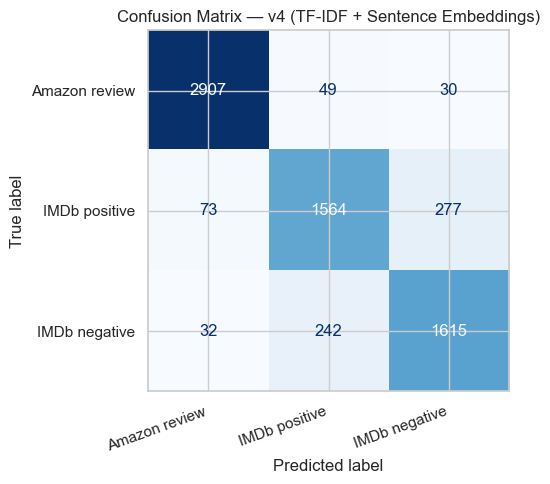

In [12]:
cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[LABEL_NAMES[i] for i in range(3)])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.xticks(rotation=20, ha='right')
plt.title('Confusion Matrix — v4 (TF-IDF + Sentence Embeddings)')
plt.tight_layout()
plt.show()

Amazon reviews (label 0) are classified nearly perfectly -- structural signals are just that strong. Almost all the mistakes are between labels 1 and 2, meaning the model can tell "this is an IMDb review" but struggles with whether it's positive or negative.

That's a pure sentiment analysis problem and it's genuinely harder. The difference between a positive and negative review can come down to sarcasm, hedging, or subtle word choices that TF-IDF isn't great at picking up. A fine-tuned transformer would probably close most of that remaining gap.

## 7. What did the model actually learn?

One thing I like about Logistic Regression is you can look at the weights and see what it's actually relying on. Useful for sanity checking that the model isn't picking up something spurious.

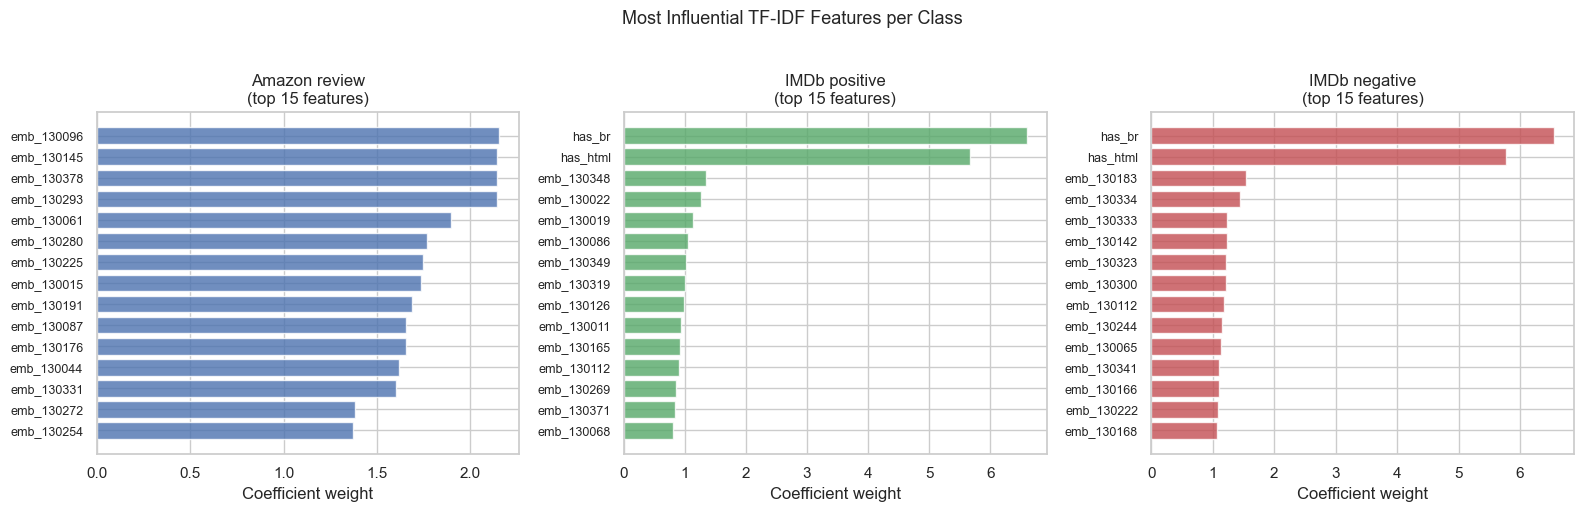

In [13]:
feature_names = (
    word_tfidf.get_feature_names_out().tolist() +
    char_tfidf.get_feature_names_out().tolist() +
    ['is_chinese', 'has_br', 'has_html', 'raw_len', 'word_count', 'avg_word_len']
)

n_top = 15
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, class_idx in zip(axes, [0, 1, 2]):
    coef = clf_v4.coef_[class_idx]
    top_idx = np.argsort(coef)[-n_top:][::-1]
    top_feats = [feature_names[i] if i < len(feature_names) else f'emb_{i}' for i in top_idx]
    top_vals  = coef[top_idx]
    colors = ['#4c72b0','#55a868','#c44e52']
    ax.barh(range(n_top), top_vals[::-1], color=colors[class_idx], alpha=0.8)
    ax.set_yticks(range(n_top))
    ax.set_yticklabels(top_feats[::-1], fontsize=9)
    ax.set_title(f'{LABEL_NAMES[class_idx]}\n(top {n_top} features)')
    ax.set_xlabel('Coefficient weight')
plt.suptitle('Most Influential TF-IDF Features per Class', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Makes sense when you look at it — Amazon class is dominated by book/product words, the IMDb classes pick up movie vocabulary, and the positive/negative split shows words you'd expect for sentiment. Nothing suspicious, which is reassuring.

## 8. Things I learned from this

**Look at your data before modeling.** The Chinese text and the HTML tag signal both came from just reading through examples. Neither would have shown up from hyperparameter tuning.

**Simple rules beat ML when the pattern is perfect.** There's no model that does better than a one-line regex on the Chinese texts. Don't use a model where a rule works.

**Implementation details matter more than you'd think.** The difference between running char TF-IDF on raw vs cleaned text was literally one line of code, and it cost ~1% accuracy when wrong.

**Combining features is often better than picking one.** TF-IDF handles domain detection, embeddings handle sentiment. Neither alone is as good as both together.

**`class_weight='balanced'` isn't always the right call.** With a mild 46/27/27 imbalance, forcing balance hurt more than it helped. Worth testing both.

**The hard part is sentiment.** Labels 0 vs 1/2 are easy because they have structural differences. Labels 1 vs 2 are hard because they require understanding tone and nuance -- that's where a fine-tuned transformer would actually make a difference.

---

## 9. How to run this

**With Docker:**
```bash
docker build -t ling539 .
docker run -v $(pwd)/data:/app/data ling539 python solution_v4.py
```

**Locally:**
```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt

# v3 must run before v4 since v4 reuses saved embeddings
python solution_v2.py   # TF-IDF + LogReg
python solution_v3.py   # sentence embeddings (saves to models/)
python solution_v4.py   # combined -- best result
```